# RQ3 — Challenges and Support (Q21–Q22)

**Analysis to Address RQ3**: Q21–Q22 — main challenges to guarantee data reliability and frequency of support from other teams.

In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
print(f"N={len(df)}")


N=56


In [23]:
Q21_OPTIONS = U.Q21_OPTIONS
Q21_LABELS  = dict(U.Q21_LABELS)

## Q21 & Q22 Bar Plot

C:\Users\kevin\AppData\Local\Temp\ipykernel_17180\1179915923.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.5)


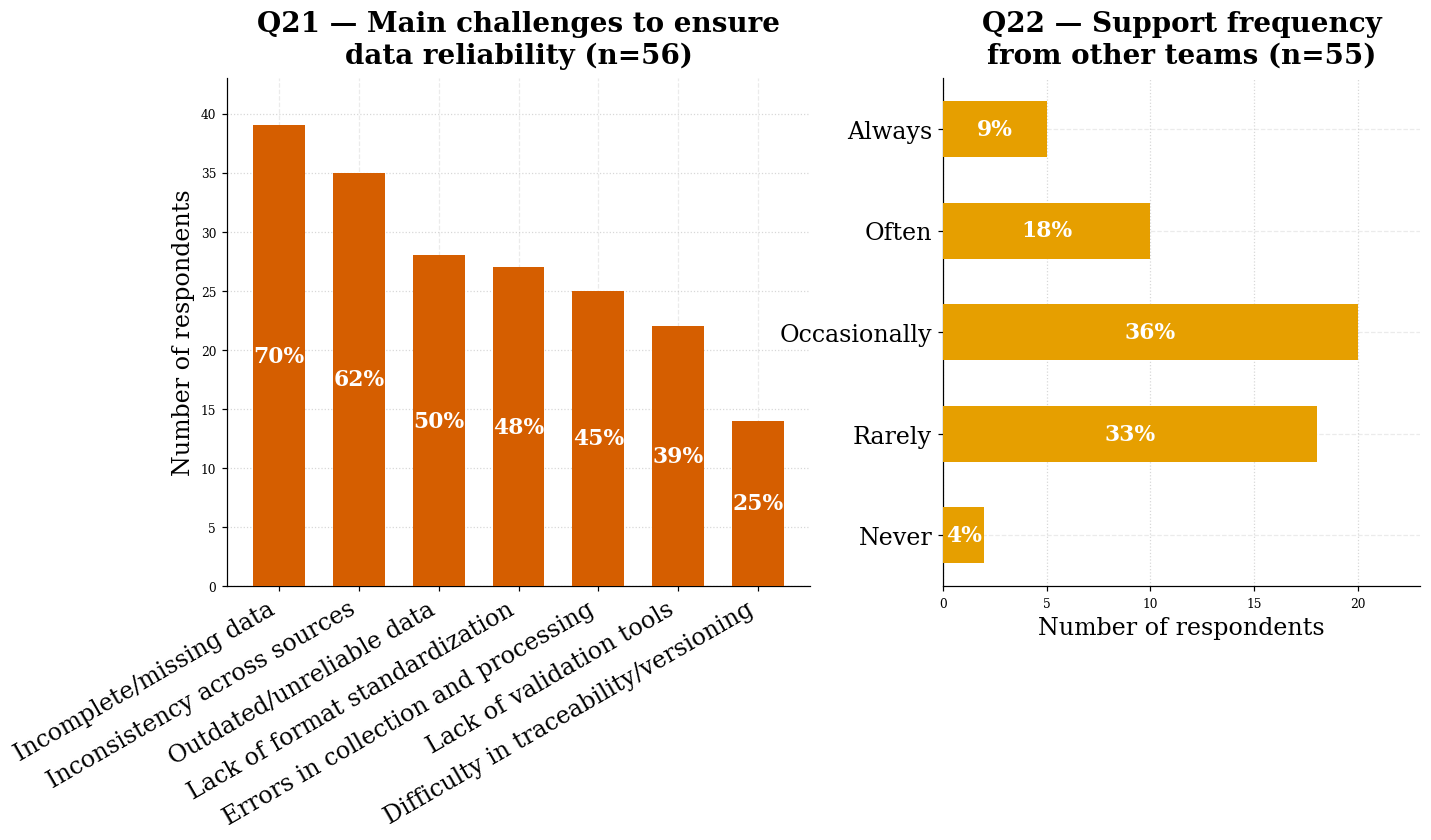

In [26]:
q21_bin, q21_res = U.parse_checkboxes(df["challenges_open"], Q21_OPTIONS)
n_q21 = df["challenges_open"].notna().sum()
p21 = U.proportions_with_ci(q21_bin, Q21_LABELS, n_q21)
p21_sorted = p21.sort_values("pct", ascending=False).reset_index(drop=True)

q22_counts = df["support_freq"].value_counts(dropna=True).reindex(U.Q22_ORDER, fill_value=0)
n_q22      = int(q22_counts.sum())
n_max_q22  = int(q22_counts.max())
q22_pct    = (q22_counts / n_q22 * 100).values

FS_TITLE = 14*1.3
FS_TICK  = 12*1.3
FS_BAR   = 11*1.3

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [5.5, 4.5], "wspace": 0.25},
)

x1 = np.arange(len(p21_sorted))
ax1.bar(x1, p21_sorted["n"], color=U.PALETTE_WONG[6], width=0.65, zorder=3)

n_max_q21 = p21_sorted["n"].max()
for i, row in p21_sorted.iterrows():
    ax1.text(i, row["n"] / 2, f"{row['pct']:.0f}%",
             ha="center", va="center", fontsize=FS_BAR, fontweight="bold", color="white")

ax1.set_xticks(x1)
ax1.set_xticklabels(p21_sorted["label"], fontsize=FS_TICK, ha="right", rotation=30)
ax1.set_ylabel("Number of respondents", fontsize=FS_TICK)
ax1.set_ylim(0, n_max_q21 + 4)
ax1.set_title(
    f"Q21 — Main challenges to ensure\ndata reliability (n={n_q21})",
    fontsize=FS_TITLE, fontweight="bold", pad=10,
)
ax1.yaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax1.set_axisbelow(True)
for sp in ["top", "right"]:
    ax1.spines[sp].set_visible(False)

y2 = np.arange(len(U.Q22_LABELS))
ax2.barh(y2, q22_counts.values, color=U.PALETTE_WONG[1], height=0.55, zorder=3)

for i, (pct, cnt) in enumerate(zip(q22_pct, q22_counts.values)):
    ax2.text(cnt / 2, i, f"{pct:.0f}%",
             ha="center", va="center", fontsize=FS_BAR, fontweight="bold", color="white")

ax2.set_yticks(y2)
ax2.set_yticklabels(U.Q22_LABELS, fontsize=FS_TICK)
ax2.set_xlabel("Number of respondents", fontsize=FS_TICK)
ax2.set_xlim(0, n_max_q22 + 3)
ax2.invert_yaxis()
ax2.set_title(
    f"Q22 — Support frequency\nfrom other teams (n={n_q22})",
    fontsize=FS_TITLE, fontweight="bold", pad=10,
)
ax2.xaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax2.set_axisbelow(True)
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)

fig.tight_layout(pad=0.5)
U.save_fig(fig, "challenges_support_q21_q22")
plt.show()